Level 1 numpy Foundation

In [ ]:
import numpy as np

# Normal Python list
my_list = [1, 2, 3, 4, 5]

# NumPy array (faster, more powerful)
my_array = np.array([1, 2, 3, 4, 5])

print(my_array)        # [1 2 3 4 5]
print(type(my_array))  # <class 'numpy.ndarray'>

[1 2 3 4 5]
<class 'numpy.ndarray'>


In [ ]:
import numpy as np

arr = np.array([10, 20, 30, 40, 50])

# Basic math — applied to ALL elements at once
print(arr + 5)      # [15 25 35 45 55]
print(arr * 2)      # [20 40 60 80 100]
print(arr ** 2)     # [100 400 900 1600 2500]

# Statistics
print(np.mean(arr))    # Average → 30.0
print(np.median(arr))  # Middle value → 30.0
print(np.std(arr))     # Standard deviation → 14.14
print(np.max(arr))     # Maximum → 50
print(np.min(arr))     # Minimum → 10
print(np.sum(arr))     # Total → 150

[15 25 35 45 55]
[ 20  40  60  80 100]
[ 100  400  900 1600 2500]
30.0
30.0
14.142135623730951
50
10
150


In [ ]:
import numpy as np

# 2D array = rows and columns
matrix = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
])

print(matrix.shape)     # (3, 3) → 3 rows, 3 columns
print(matrix[0])        # First row → [1, 2, 3]
print(matrix[0][1])     # Row 0, Column 1 → 2
print(matrix[:, 1])     # All rows, column 1 → [2, 5, 8]

(3, 3)
[1 2 3]
2
[2 5 8]


Level 2 Pandas

Creating Data Frames

In [ ]:
import pandas as pd

# Create data manually
data = {
    'Name':   ['Alice', 'Bob', 'Charlie', 'Diana', 'Eve'],
    'Age':    [25, 30, 35, 28, 22],
    'Salary': [50000, 70000, 90000, 65000, 45000],
    'Dept':   ['HR', 'IT', 'IT', 'Finance', 'HR']
}

df = pd.DataFrame(data)
print(df)

      Name  Age  Salary     Dept
0    Alice   25   50000       HR
1      Bob   30   70000       IT
2  Charlie   35   90000       IT
3    Diana   28   65000  Finance
4      Eve   22   45000       HR


Reading real Data files


In [ ]:
# Read from CSV (most common)
df = pd.read_csv('sales_data.csv')

# Read from Excel
df = pd.read_excel('report.xlsx')

# Read from JSON
df = pd.read_json('data.json')

# Save back to CSV
df.to_csv('output.csv', index=False)

FileNotFoundError: [Errno 2] No such file or directory: 'sales_data.csv'

Selecting Data

In [ ]:
# Select one column
df['Name']
df.Name

# Select multiple columns
df[['Name', 'Salary']]

# Select rows by index number
df.iloc[0]       # First row
df.iloc[0:3]     # First 3 rows

# Select rows by condition
df[df['Age'] > 28]              # Rows where age > 28
df[df['Dept'] == 'IT']          # Only IT department
df[df['Salary'] > 60000]        # High earners

# Multiple conditions
df[(df['Dept'] == 'IT') & (df['Age'] > 28)]

,Name,Age,Salary,Dept
1,Bob,30,70000,IT
2,Charlie,35,90000,IT


Data Cleaning

In [ ]:
# Check missing values
df.isnull().sum()

# Fill missing values
df['Salary'].fillna(0, inplace=True)           # Fill with 0
df['Salary'].fillna(df['Salary'].mean(), inplace=True)  # Fill with average

# Drop rows with missing values
df.dropna(inplace=True)

# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Rename columns
df.rename(columns={'Name': 'Employee', 'Dept': 'Department'}, inplace=True)

# Change data type
df['Age'] = df['Age'].astype(float)

/tmp/ipykernel_23520/3074772963.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Salary'].fillna(0, inplace=True)           # Fill with 0
/tmp/ipykernel_23520/3074772963.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

Sorting and grouping

In [ ]:
# Sort by salary (highest first)
df.sort_values('Salary', ascending=False)

# Group by department → find average salary
df.groupby('Dept')['Salary'].mean()

# Output:
# Dept
# Finance    65000.0
# HR         47500.0
# IT         80000.0

# Multiple aggregations at once
df.groupby('Dept').agg({
    'Salary': ['mean', 'max', 'min'],
    'Age':    ['mean']
})

KeyError: 'Dept'

Adding New Column

In [ ]:
# Create a new column based on existing ones
df['Tax'] = df['Salary'] * 0.2
df['Net Salary'] = df['Salary'] - df['Tax']

# Categorize using conditions
df['Level'] = df['Salary'].apply(
    lambda x: 'Senior' if x > 70000 else 'Junior'
)

Level 3 data Visualization

MatPlotLib basic Plotting

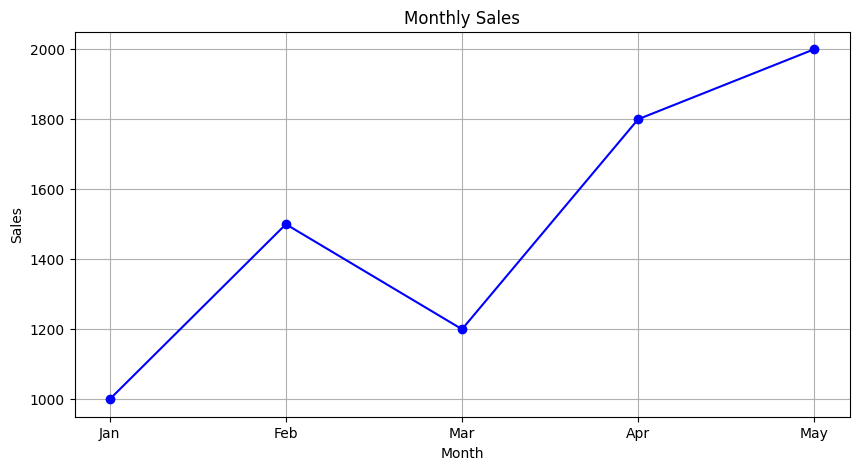

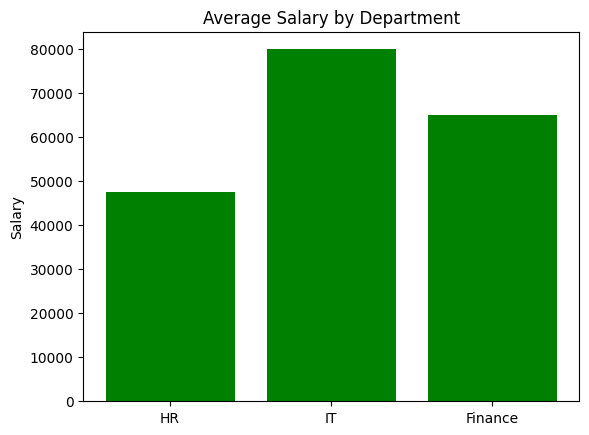

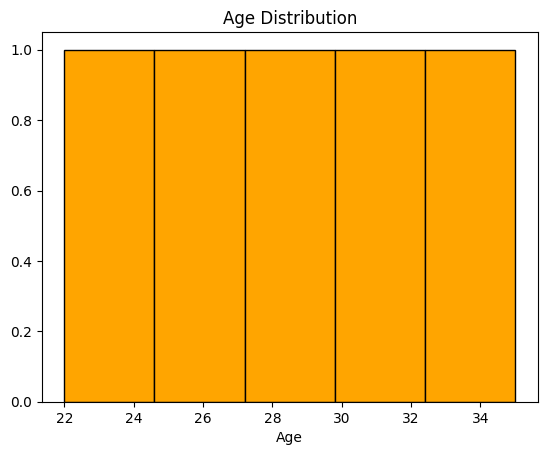

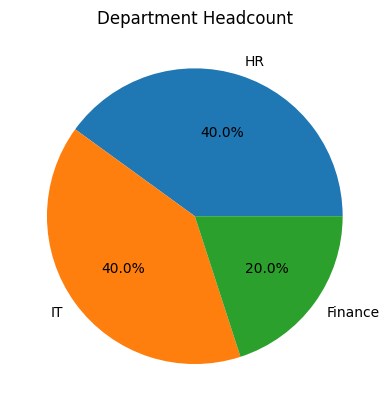

In [ ]:
import matplotlib.pyplot as plt

# Line Chart
plt.figure(figsize=(10, 5))
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May']
sales  = [1000, 1500, 1200, 1800, 2000]
plt.plot(months, sales, marker='o', color='blue')
plt.title('Monthly Sales')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.grid(True)
plt.show()

# Bar Chart
plt.bar(['HR', 'IT', 'Finance'], [47500, 80000, 65000], color='green')
plt.title('Average Salary by Department')
plt.ylabel('Salary')
plt.show()

# Histogram — shows distribution
plt.hist(df['Age'], bins=5, color='orange', edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.show()

# Pie Chart
plt.pie([2, 2, 1], labels=['HR', 'IT', 'Finance'], autopct='%1.1f%%')
plt.title('Department Headcount')
plt.show()

seabond Statistical Plots

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Scatter plot — relationship between Age and Salary
sns.scatterplot(data=df, x='Age', y='Salary', hue='Dept', size='Salary')
plt.title('Age vs Salary')
plt.show()

# Box plot — shows spread and outliers
sns.boxplot(data=df, x='Dept', y='Salary')
plt.title('Salary Distribution by Department')
plt.show()

# Heatmap — correlation between columns
correlation = df[['Age', 'Salary', 'Tax']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# Count plot — frequency of categories
sns.countplot(data=df, x='Dept', palette='Set2')
plt.title('Employee Count by Department')
plt.show()

ValueError: Could not interpret value `Age` for `x`. An entry with this name does not appear in `data`.

Statisctical Analysis

Descrispictive statistical

In [ ]:
# Central tendency
mean   = df['Salary'].mean()     # Average
median = df['Salary'].median()   # Middle value
mode   = df['Salary'].mode()[0]  # Most frequent

# Spread
std    = df['Salary'].std()      # Standard deviation
var    = df['Salary'].var()      # Variance
range_ = df['Salary'].max() - df['Salary'].min()

print(f"Mean:   {mean}")
print(f"Median: {median}")
print(f"Std:    {std:.2f}")

Mean:   64000.0
Median: 65000.0
Std:    17818.53


Correlation Anlysis

In [ ]:
# Correlation tells how two variables relate
# +1 = perfect positive, -1 = perfect negative, 0 = no relation

correlation = df['Age'].corr(df['Salary'])
print(f"Age-Salary Correlation: {correlation:.2f}")

# Full correlation matrix
df[['Age', 'Salary']].corr()

Age-Salary Correlation: 0.99


,Age,Salary
Age,1.000000,0.992095
Salary,0.992095,1.000000


Sales Data Analysis

=== BUSINESS SUMMARY ===
Total Sales:    ₹277,000
Total Expenses: ₹135,500
Total Profit:   ₹141,500
Avg Margin:     50.5%
Best Month:     Dec
Worst Month:    Mar

=== REGIONAL PERFORMANCE ===
  Region   Sales  Profit
0  North  128000   64500
1  South  149000   77000


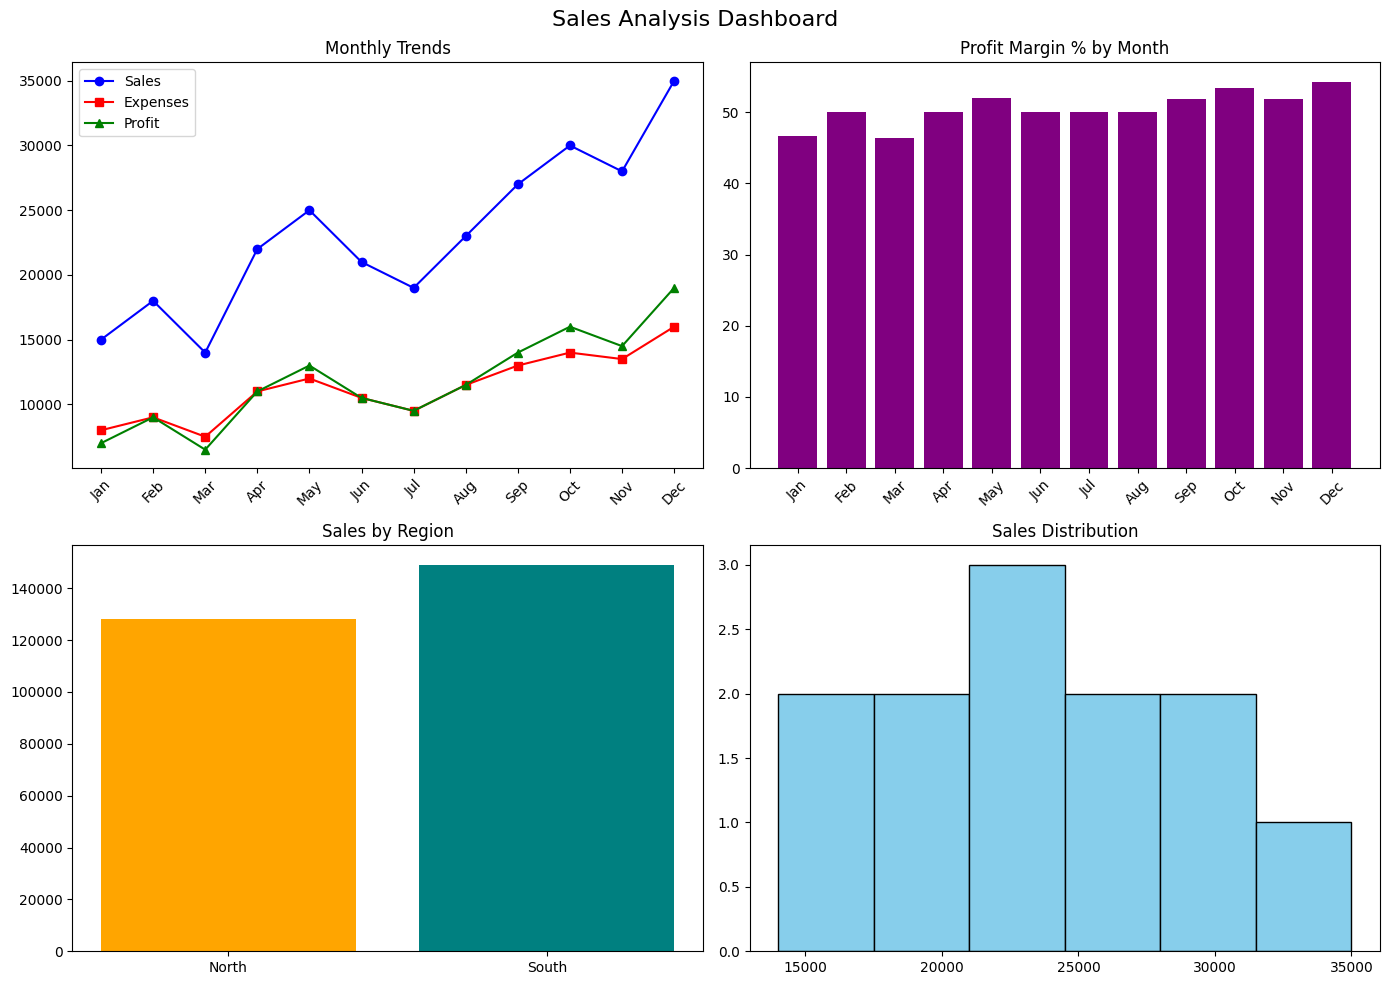

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Step 1: Create sample sales data ──────────────────
data = {
    'Month':    ['Jan','Feb','Mar','Apr','May','Jun',
                 'Jul','Aug','Sep','Oct','Nov','Dec'],
    'Sales':    [15000,18000,14000,22000,25000,21000,
                 19000,23000,27000,30000,28000,35000],
    'Expenses': [8000,9000,7500,11000,12000,10500,
                 9500,11500,13000,14000,13500,16000],
    'Region':   ['North','South','North','South','North',
                 'South','North','South','North','South',
                 'North','South']
}

df = pd.DataFrame(data)

# ── Step 2: Add calculated columns ────────────────────
df['Profit'] = df['Sales'] - df['Expenses']
df['Profit_Margin'] = (df['Profit'] / df['Sales'] * 100).round(2)

# ── Step 3: Summary Statistics ────────────────────────
print("=== BUSINESS SUMMARY ===")
print(f"Total Sales:    ₹{df['Sales'].sum():,}")
print(f"Total Expenses: ₹{df['Expenses'].sum():,}")
print(f"Total Profit:   ₹{df['Profit'].sum():,}")
print(f"Avg Margin:     {df['Profit_Margin'].mean():.1f}%")
print(f"Best Month:     {df.loc[df['Sales'].idxmax(), 'Month']}")
print(f"Worst Month:    {df.loc[df['Sales'].idxmin(), 'Month']}")

# ── Step 4: Regional Analysis ─────────────────────────
regional = df.groupby('Region').agg({
    'Sales':   'sum',
    'Profit':  'sum'
}).reset_index()
print("\n=== REGIONAL PERFORMANCE ===")
print(regional)

# ── Step 5: Visualizations ────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Sales Analysis Dashboard', fontsize=16)

# Chart 1 - Sales trend
axes[0,0].plot(df['Month'], df['Sales'], marker='o', color='blue', label='Sales')
axes[0,0].plot(df['Month'], df['Expenses'], marker='s', color='red', label='Expenses')
axes[0,0].plot(df['Month'], df['Profit'], marker='^', color='green', label='Profit')
axes[0,0].set_title('Monthly Trends')
axes[0,0].legend()
axes[0,0].tick_params(axis='x', rotation=45)

# Chart 2 - Profit margin
axes[0,1].bar(df['Month'], df['Profit_Margin'], color='purple')
axes[0,1].set_title('Profit Margin % by Month')
axes[0,1].tick_params(axis='x', rotation=45)

# Chart 3 - Regional sales
axes[1,0].bar(regional['Region'], regional['Sales'], color=['orange','teal'])
axes[1,0].set_title('Sales by Region')

# Chart 4 - Sales distribution
axes[1,1].hist(df['Sales'], bins=6, color='skyblue', edgecolor='black')
axes[1,1].set_title('Sales Distribution')

plt.tight_layout()
plt.show()